## MC Dropout : Heat conduction

**Inputs:**
| Variable | Description | Units |
|----------|-------------|-------|
| `qprime` | Linear heat generation rate | W/m |
| `mdot`   | Mass flow rate | g/s |
| `Tin`    | Temperature at fuel boundary | K |
| `R`      | Fuel radius | m |
| `L`      | Fuel length | m |
| `Cp`     | Heat capacity | J/(g·K) |
| `k`      | Thermal conductivity | W/(m·K) |

**Output:**
- `T`: Fuel centerline temperature (K

## MC Dropout

Standard neural networks produce a single point estimate with no measure of confidence. MC Dropout approximates Bayesian inference:

1. Train a network with dropout layers. (they act as regularisation during training)
2. At inference time, keep dropout active by calling the model with `training=True`
3. Run N stochastic forward passes — each applies a different random dropout mask, effectively sampling a different thinned sub-network
4. Treat the N predictions as samples from an approximate posterior predictive distribution

no architecture changes beyond standard dropout, no extra parameters.

## 1. Imports

In [178]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# print(f'TensorFlow : {tf.__version__}')
# print(f'NumPy      : {np.__version__}')
# print(f'Seed       : {SEED}')

## 2. Data Loading and Exploration

In [179]:
# Load data from directory
df = pd.read_csv('heat.csv')

print(f'Dataset shape  : {df.shape}  ({df.shape[0]} samples, {df.shape[1]} columns)')
print(f'Missing values : {df.isnull().sum().sum()}')
print()
df.head()

Dataset shape  : (1000, 8)  (1000 samples, 8 columns)
Missing values : 0



,qprime,mdot,Tin,R,L,Cp,k,T
0,35987.992759,206.185816,573.151869,0.004901,3.448155,4.096140,0.960945,1034.133784
1,38481.055798,192.378974,573.150960,0.004966,3.436833,4.249182,1.011272,1170.316042
2,39143.292108,205.076928,573.153975,0.005210,3.681457,4.237540,0.994646,1164.893565
3,38687.579644,199.594924,573.150777,0.004864,3.624594,4.158921,1.028158,1205.250040
4,40469.561181,194.142084,573.150977,0.004914,3.731222,4.244278,1.018738,1444.718666


In [180]:
df.describe()

,qprime,mdot,Tin,R,L,Cp,k,T
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,39998.464656,199.994370,573.152500,0.005000,3.659950,4.185981,1.000005,1300.603981
std,2004.435200,10.005739,0.001444,0.000250,0.183108,0.083734,0.029983,152.821293
min,32126.997674,164.258253,573.150002,0.004000,3.021978,3.895158,0.903600,1002.093321
25%,38652.476069,193.260262,573.151251,0.004831,3.536546,4.129630,0.979782,1158.486460
50%,39999.251425,200.000704,573.152498,0.005000,3.660208,4.186059,1.000022,1293.477602
75%,41348.808146,206.732390,573.153748,0.005168,3.783241,4.242295,1.020186,1439.004835
max,46573.973586,231.731570,573.154997,0.005777,4.264208,4.454367,1.097362,1671.881700


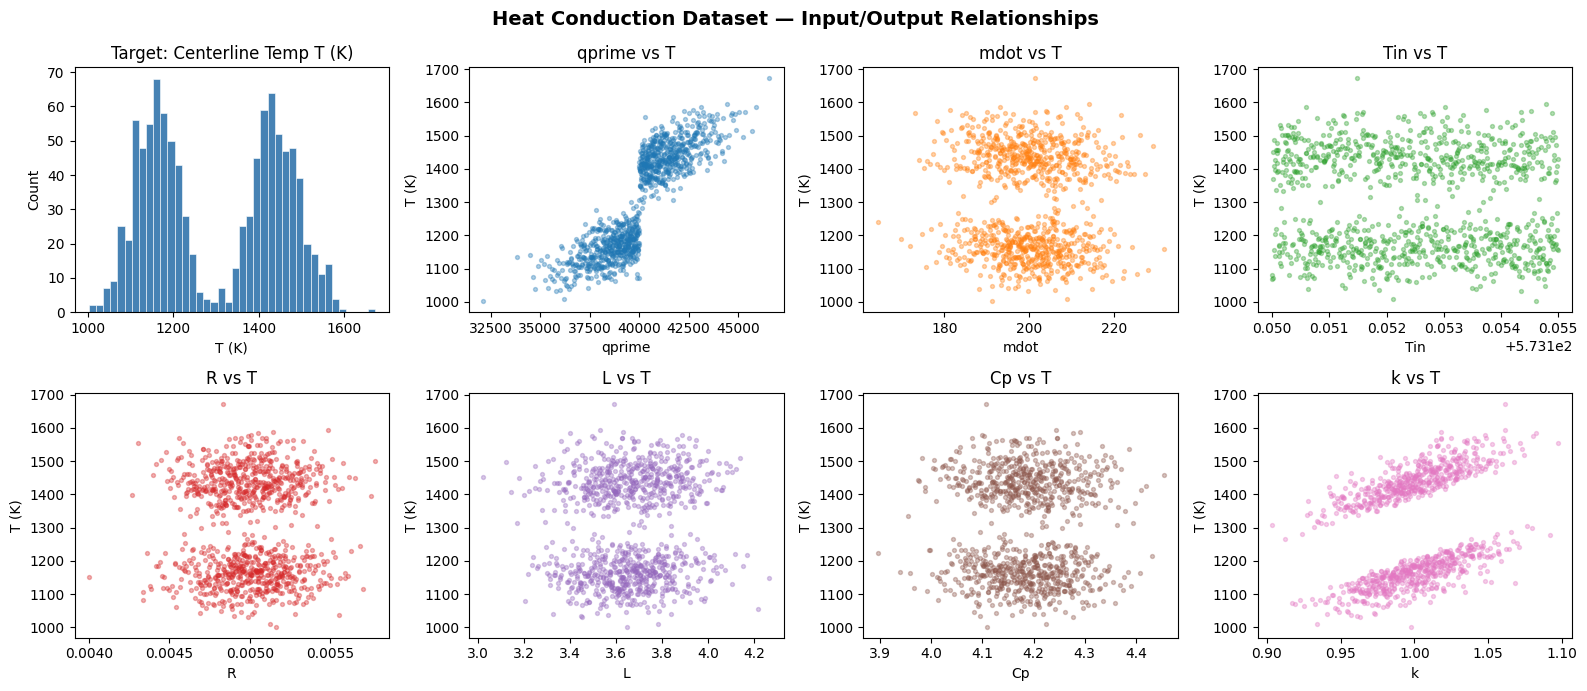

In [181]:
# Visualise relationships between each input and target temperature T
INPUT_COLS = ['qprime', 'mdot', 'Tin', 'R', 'L', 'Cp', 'k']
OUTPUT_COL = 'T'

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()

axes[0].hist(df[OUTPUT_COL], bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Target: Centerline Temp T (K)')
axes[0].set_xlabel('T (K)'); axes[0].set_ylabel('Count')

colors = plt.cm.tab10.colors
for i, col in enumerate(INPUT_COLS):
    axes[i + 1].scatter(df[col], df[OUTPUT_COL], s=8, alpha=0.35, color=colors[i])
    axes[i + 1].set_xlabel(col); axes[i + 1].set_ylabel('T (K)')
    axes[i + 1].set_title(f'{col} vs T')

fig.suptitle('Heat Conduction Dataset — Input/Output Relationships', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:** qprime and Tin shows positive relationships with T. K shows a clear inverse relationship

In [182]:
# # Physics-informed feature engineering
# df['qprime_over_k'] = df['qprime'] / df['k']   # dominant ratio in temperature rise
# df['R_squared']     = df['R'] ** 2              # appears explicitly in the formula
# #INPUT_COLS = ['qprime', 'mdot', 'Tin', 'R', 'L', 'Cp', 'k']
# FEATURE_COLS = ['qprime', 'mdot', 'Tin', 'R', 'L', 'Cp', 'k', 'qprime_over_k', 'R_squared']
# print(f'Features ({len(FEATURE_COLS)} total): {FEATURE_COLS}')

## 3. Train/Test Split and Standard Scaling

- 70% train / 30% test split
- using StandardScaler(), Centers data around 0 mean and 1 standard deviation
- Output scaler (`y_scaler`) is preserved to inverse-transform predictions

In [183]:
X = df[INPUT_COLS].values.astype(np.float32)
y = df[OUTPUT_COL].values.astype(np.float32).reshape(-1, 1)

# 70/30 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED
)

# Min-Max scaling — fit on TRAIN only to avoid leaking test statistics
#x_scaler  = MinMaxScaler()
#x_scaler  =RobustScaler
#x_scaler  =MaxAbsScaler()
x_scaler  = StandardScaler()
X_train_s = x_scaler.fit_transform(X_train)
X_test_s  = x_scaler.transform(X_test)

y_scaler  =StandardScaler()
#y_scaler  = MinMaxScaler()
#y_scaler  =MaxAbsScaler()
y_train_s = y_scaler.fit_transform(y_train)

print(f'Training samples : {X_train_s.shape[0]}')
print(f'Test samples     : {X_test_s.shape[0]}')
print(f'Input features   : {X_train_s.shape[1]}')
print(f'y_train range (scaled) : [{y_train_s.min():.3f}, {y_train_s.max():.3f}]')

Training samples : 700
Test samples     : 300
Input features   : 7
y_train range (scaled) : [-1.924, 2.381]


## 4. Model Architecture — MC Dropout Neural Network

### Design Decisions

| Choice | Value                                  | reason                                                                                  |
|--------|----------------------------------------|-----------------------------------------------------------------------------------------|
| Hidden layers | 4                                      | like the branchmaek                                                                     |
| Units per layer | 256 , 256 , 128 , 64                   | move the layer size down after each layer can pervent Overfitting                       |
| Activation | ReLU                                   | Standard activation function                                                            |
| Dropout rate | 0.1                                    | Normal dropout rate to use                                                              |
| MC Dropout  | `model(X, training=True)` at inference | Passes the training flag through the full call graph, keeping all Dropout layers active |
| Loss | MSE                                    |                                                                                         |
| Optimizer | Adam lr=0.001                          |                                                                                         |


In [184]:
#hyperparameters
DROPOUT_RATE  = 0.1
LEARNING_RATE = 1e-3
BATCH_SIZE    = 32
MAX_EPOCHS    = 600
MC_SAMPLES    = 100   # number of stochastic forward passes at inference


def build_mc_dropout_model(input_dim: int, dropout_rate: float = DROPOUT_RATE) -> keras.Model:

    inputs = keras.Input(shape=(input_dim,), name='inputs')

    x = layers.Dense(256, activation='relu', kernel_initializer='he_normal', name='dense_1')(inputs)
    x = layers.Dropout(dropout_rate, name='dropout_1')(x)

    x = layers.Dense(256, activation='relu', kernel_initializer='he_normal', name='dense_2')(x)
    x = layers.Dropout(dropout_rate, name='dropout_2')(x)

    x = layers.Dense(128, activation='relu', kernel_initializer='he_normal', name='dense_3')(x)
    x = layers.Dropout(dropout_rate, name='dropout_3')(x)

    x = layers.Dense(64, activation='relu', kernel_initializer='he_normal', name='dense_4')(x)
    x = layers.Dropout(dropout_rate, name='dropout_4')(x)

    output = layers.Dense(1, activation='linear', name='output')(x)

    return keras.Model(inputs=inputs, outputs=output, name='MC_Dropout_Net')


model = build_mc_dropout_model(input_dim=X_train_s.shape[1])
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='mse',
    metrics=['mae'],
)
model.summary()

Model: "MC_Dropout_Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,057 (426.00 KB)

 Trainable params: 109,057 (426.00 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training

In [185]:
# Callbacks: EarlyStopping restores best weights; ReduceLROnPlateau fine-tunes
# early_stop = keras.callbacks.EarlyStopping(
#     monitor='val_loss', patience=40, restore_best_weights=True, verbose=1
# )
# reduce_lr = keras.callbacks.ReduceLROnPlateau(
#     monitor='val_loss', factor=0.5, patience=20, min_lr=1e-6, verbose=0
# )

# Train on scaled data; 15% of training set withheld for validation
history = model.fit(
    X_train_s, y_train_s,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    #callbacks=[early_stop, reduce_lr],
    verbose=0,
)

epochs_ran = len(history.history['loss'])
best_val   = min(history.history['val_loss'])
print(f'Training complete. Epochs: {epochs_ran}  |  Best val MSE: {best_val:.6f}')

Training complete. Epochs: 600  |  Best val MSE: 0.025993


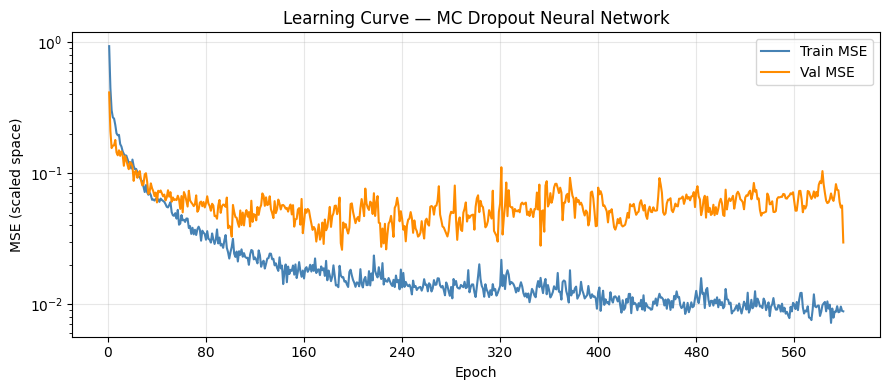

In [186]:
# Learning curve
fig, ax = plt.subplots(figsize=(9, 4))
ep = range(1, epochs_ran + 1)
ax.semilogy(ep, history.history['loss'],     label='Train MSE', color='steelblue', linewidth=1.5)
ax.semilogy(ep, history.history['val_loss'], label='Val MSE',   color='darkorange', linewidth=1.5)
# ax.plot(ep, history.history['loss'],     label='Train MSE', color='steelblue', linewidth=1.5)
# ax.plot(ep, history.history['val_loss'], label='Val MSE',   color='darkorange', linewidth=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled space)')
ax.set_title('Learning Curve — MC Dropout Neural Network')
ax.legend(); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout(); plt.show()

## 6. MC Dropout Inference

With the trained model, we perform MC Dropout inference. Calling `model(X, training=True)` N times produces N predictions with different random dropout masks. The spread across predictions is our uncertainty estimate.


In [187]:
def mc_predict(model, X, n_samples: int = MC_SAMPLES):
    """
    Run n_samples stochastic forward passes.

    model(X, training=True) propagates the training flag to all layers,
    keeping Dropout active. Each call uses a different random mask,
    so repeated calls produce different outputs.

    Returns: ndarray of shape (n_samples, n_data) in scaled output space.
    """
    return np.stack(
        [model(X, training=True).numpy().ravel() for _ in range(n_samples)],
        axis=0
    )

raw_scaled = mc_predict(model, X_test_s.astype(np.float32))
print(f'Prediction matrix shape : {raw_scaled.shape}  (n_passes x n_test)')
print(f'Std dev range (scaled)  : [{raw_scaled.std(axis=0).min():.4f}, {raw_scaled.std(axis=0).max():.4f}]')

# Inverse-transform all MC samples back to Kelvin
preds_K   = y_scaler.inverse_transform(raw_scaled.T).T
print(preds_K)

# summary
mean_pred = preds_K.mean(axis=0)
std_pred  = preds_K.std(axis=0)
ci_lo     = np.percentile(preds_K, 2.5,  axis=0)   # 95% CI lower
ci_hi     = np.percentile(preds_K, 97.5, axis=0)   # 95% CI upper

y_true = y_test.ravel()

print(f'  Mean range : [{mean_pred.min():.1f}, {mean_pred.max():.1f}]')
print(f'  Std range  : [{std_pred.min():.1f}, {std_pred.max():.1f}]')
print(f'  CI widths  : [{(ci_hi - ci_lo).min():.1f}, {(ci_hi - ci_lo).max():.1f}]')

Prediction matrix shape : (100, 300)  (n_passes x n_test)
Std dev range (scaled)  : [0.0494, 0.4582]
[[1559.5227 1365.168  1404.2892 ... 1384.5337 1139.7596 1468.4423]
 [1507.7241 1357.6075 1422.1078 ... 1372.7609 1141.5989 1458.2654]
 [1549.8353 1361.1483 1437.8922 ... 1390.0908 1138.695  1468.0988]
 ...
 [1508.4287 1362.157  1434.1099 ... 1373.4125 1147.597  1456.1031]
 [1570.063  1362.0793 1415.5315 ... 1370.6592 1130.6516 1464.9235]
 [1544.1644 1354.7168 1416.9783 ... 1352.5745 1123.0481 1459.5168]]
  Mean range : [1049.3, 1572.3]
  Std range  : [7.7, 71.3]
  CI widths  : [29.0, 218.3]


## 7. Performance Metrics

(R², RMSE, MAE) and the UQ-specific 95% CI coverage.

In [188]:
# Regression metrics on the MC mean prediction
r2   = r2_score(y_true, mean_pred)
rmse = np.sqrt(mean_squared_error(y_true, mean_pred))
mae  = mean_absolute_error(y_true, mean_pred)

# Calibration: what fraction of true values fall within the 95% CI?
within_ci  = (y_true >= ci_lo) & (y_true <= ci_hi)
coverage   = within_ci.mean() * 100
mean_width = (ci_hi - ci_lo).mean()

print(f'  R2:  {r2:.4f}')
print(f'  RMSE:  {rmse:.2f} K')
print(f'  MAE:  {mae:.2f} K')
print('\n')
print(f'  95% CI Coverage:  {coverage:.1f}% ')
print(f'  Mean CI Width:  {mean_width:.2f} K')
print(f'  Mean Predictive Std:  {std_pred.mean():.2f} K')


  R2:  0.9514
  RMSE:  32.17 K
  MAE:  11.52 K


  95% CI Coverage:  95.3% 
  Mean CI Width:  58.52 K
  Mean Predictive Std:  15.86 K


## 8. Calibration Analysis

Calibration Table
 Target CI (%) Actual Coverage (%) Delta (pp)
            50                80.0      +30.0
            75                92.0      +17.0
            90                93.3       +3.3
            95                95.3       +0.3
            99                96.7       -2.3


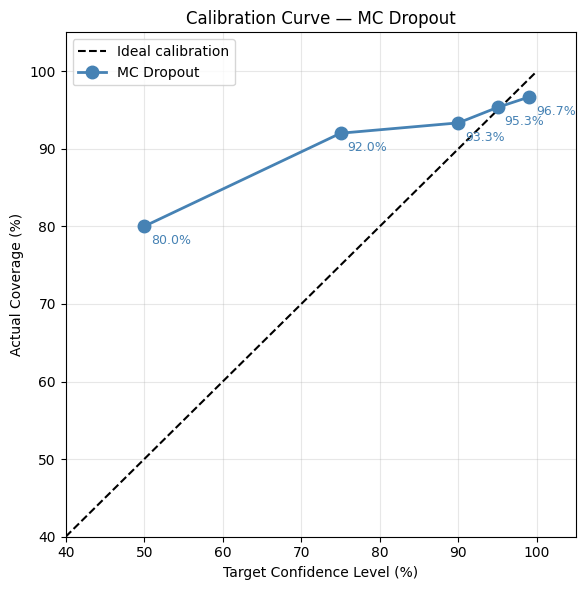

In [189]:
# confidence levels
confidence_levels = [50, 75, 90, 95, 99]
actual_coverages  = []

for conf in confidence_levels:
    alpha  = (100 - conf) / 2
    lo_tmp = np.percentile(preds_K, alpha, axis=0)
    hi_tmp = np.percentile(preds_K, 100 - alpha, axis=0)
    actual_coverages.append(np.mean((y_true >= lo_tmp) & (y_true <= hi_tmp)) * 100)

calib_df = pd.DataFrame({
    'Target CI (%)':       confidence_levels,
    'Actual Coverage (%)': [f'{c:.1f}' for c in actual_coverages],
    'Delta (pp)':          [f'{a - t:+.1f}' for a, t in zip(actual_coverages, confidence_levels)],
})
print('Calibration Table')
print(calib_df.to_string(index=False))

# Calibration curve
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 100], [0, 100], 'k--', linewidth=1.5, label='Ideal calibration')
ax.plot(confidence_levels, actual_coverages, 'o-', color='steelblue',
        linewidth=2, markersize=9, label='MC Dropout')
for t, a in zip(confidence_levels, actual_coverages):
    ax.annotate(f'{a:.1f}%', xy=(t, a), xytext=(5, -13),
                textcoords='offset points', fontsize=9, color='steelblue')
ax.set_xlabel('Target Confidence Level (%)'); ax.set_ylabel('Actual Coverage (%)')
ax.set_title('Calibration Curve — MC Dropout')
ax.set_xlim(40, 105); ax.set_ylim(40, 105)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Visualisations

### 9.1 Parity Plot with Uncertainty Bands

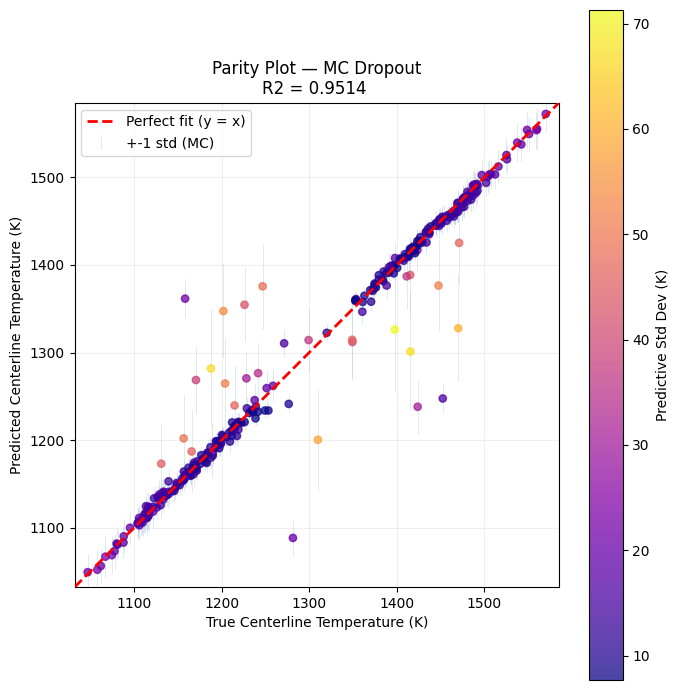

In [190]:
# Parity plot — predicted vs true with MC std error bars
# Colour encodes predictive uncertainty: bright = high uncertainty
fig, ax = plt.subplots(figsize=(7, 7))

ax.errorbar(y_true, mean_pred, yerr=std_pred, fmt='none',
            ecolor='lightsteelblue', alpha=0.4, linewidth=0.7, label='+-1 std (MC)')

sc = ax.scatter(y_true, mean_pred, c=std_pred, cmap='plasma', s=28, alpha=0.75, zorder=3)
plt.colorbar(sc, ax=ax, label='Predictive Std Dev (K)')

lims = [y_true.min() - 15, y_true.max() + 15]
ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect fit (y = x)', zorder=5)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('True Centerline Temperature (K)')
ax.set_ylabel('Predicted Centerline Temperature (K)')
ax.set_title(f'Parity Plot — MC Dropout\nR2 = {r2:.4f} ')
ax.legend(fontsize=10); ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

### 9.2 Predictions with 95% CI

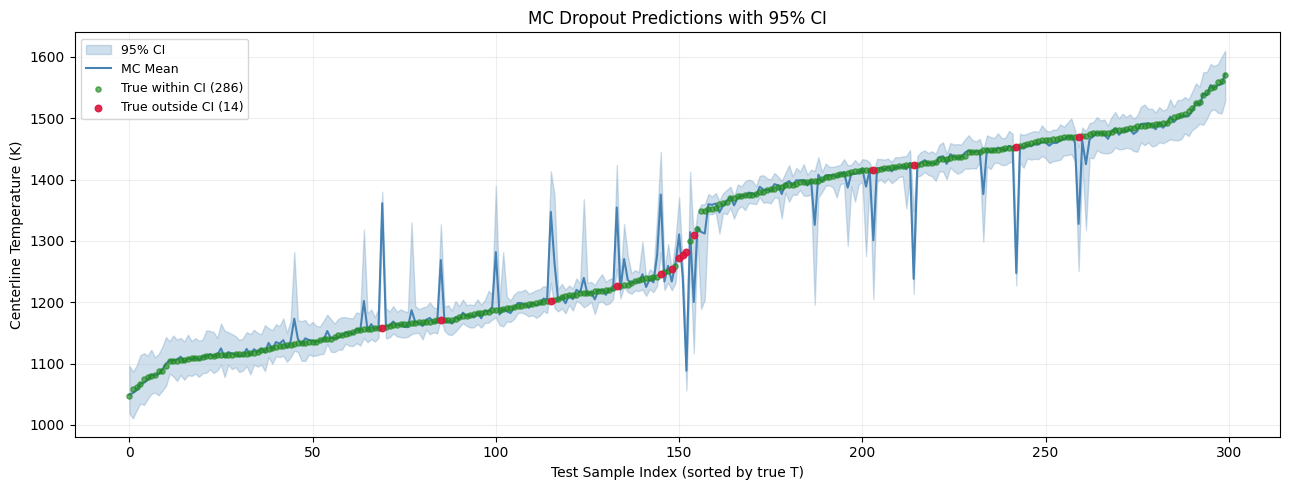

In [191]:
# Sort by true temperature for a clean ribbon plot
order    = np.argsort(y_true)
y_s      = y_true[order]
mu_s     = mean_pred[order]
lo_s     = ci_lo[order]
hi_s     = ci_hi[order]
within_s = within_ci[order]
idx      = np.arange(len(y_s))

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(idx, lo_s, hi_s, alpha=0.25, color='steelblue', label='95% CI')
ax.plot(idx, mu_s, color='steelblue', linewidth=1.5, label='MC Mean')
ax.scatter(idx[ within_s], y_s[ within_s], s=14, color='forestgreen', alpha=0.65,
           zorder=3, label=f'True within CI ({within_s.sum()})')
ax.scatter(idx[~within_s], y_s[~within_s], s=22, color='crimson', alpha=0.9,
           zorder=4, label=f'True outside CI ({(~within_s).sum()})')
ax.set_xlabel('Test Sample Index (sorted by true T)')
ax.set_ylabel('Centerline Temperature (K)')
ax.set_title(f'MC Dropout Predictions with 95% CI')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

### 9.3 Distribution for an Individual Test Sample

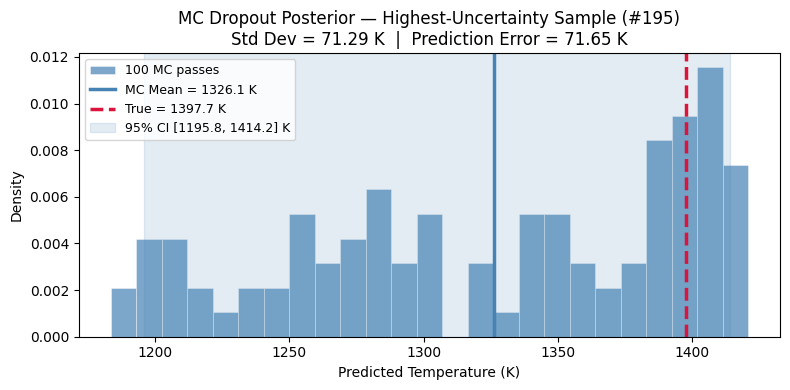

In [193]:
# Show the highest-uncertainty test sample
sample_idx   = np.argmax(std_pred)
sample_preds = preds_K[:, sample_idx]

s_mean = sample_preds.mean()
s_std  = sample_preds.std()
s_lo   = np.percentile(sample_preds, 2.5)
s_hi   = np.percentile(sample_preds, 97.5)
s_true = y_true[sample_idx]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sample_preds, bins=25, color='steelblue', edgecolor='white',
        linewidth=0.4, density=True, alpha=0.7, label=f'{MC_SAMPLES} MC passes')
ax.axvline(s_mean, color='steelblue', linewidth=2.5, label=f'MC Mean = {s_mean:.1f} K')
ax.axvline(s_true, color='crimson',   linewidth=2.5, linestyle='--',
           label=f'True = {s_true:.1f} K')
ax.axvspan(s_lo, s_hi, alpha=0.15, color='steelblue',
           label=f'95% CI [{s_lo:.1f}, {s_hi:.1f}] K')
ax.set_xlabel('Predicted Temperature (K)'); ax.set_ylabel('Density')
ax.set_title(
    f'MC Dropout Posterior — Highest-Uncertainty Sample (#{sample_idx})\n'
    f'Std Dev = {s_std:.2f} K  |  Prediction Error = {abs(s_mean - s_true):.2f} K'
)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()